# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 163s 1us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

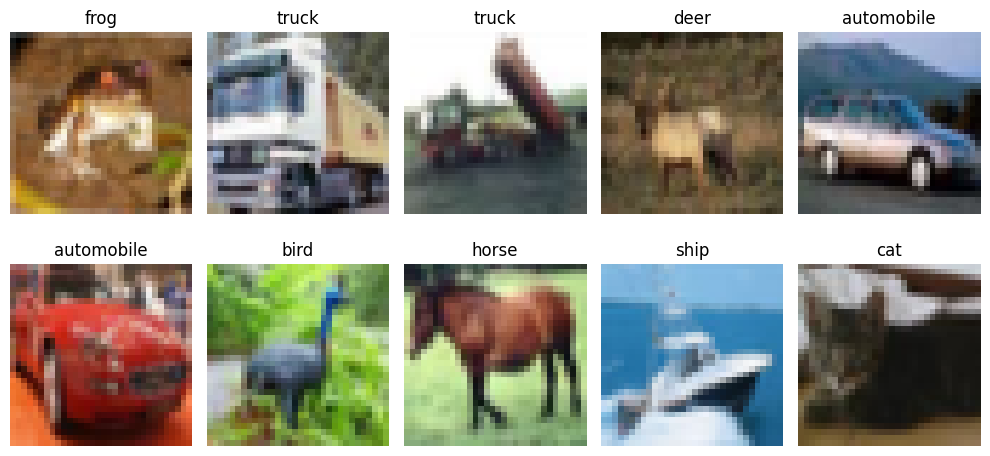

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [7]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.2712 - loss: 1.9901 - val_accuracy: 0.3328 - val_loss: 1.8724
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3162 - loss: 1.8626 - val_accuracy: 0.3572 - val_loss: 1.7742
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.3336 - loss: 1.8236 - val_accuracy: 0.3666 - val_loss: 1.7572
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.3493 - loss: 1.7845 - val_accuracy: 0.3964 - val_loss: 1.7139
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3612 - loss: 1.7556 - val_accuracy: 0.3914 - val_loss: 1.7111
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step - accuracy: 0.3705 - loss: 1.7371 - val_accuracy: 0.4036 - val_loss: 1.6846
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.3786 - loss: 1.7100 - val_accuracy: 0.4000 - val_loss: 1.7056
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.3848 - loss: 1.6967 - 

In [9]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4268 - loss: 1.6390
ANN Test Accuracy: 0.426800012588501


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [11]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 62s 81ms/step - accuracy: 0.4617 - loss: 1.4995 - val_accuracy: 0.5364 - val_loss: 1.2884
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 53s 75ms/step - accuracy: 0.6157 - loss: 1.1038 - val_accuracy: 0.5778 - val_loss: 1.2512
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 76s 66ms/step - accuracy: 0.6756 - loss: 0.9329 - val_accuracy: 0.5984 - val_loss: 1.2295
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.7159 - loss: 0.8136 - val_accuracy: 0.5354 - val_loss: 1.4993
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 54s 76ms/step - accuracy: 0.7488 - loss: 0.7226 - val_accuracy: 0.7190 - val_loss: 0.8547
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 60s 85ms/step - accuracy: 0.7720 - loss: 0.6463 - val_accuracy: 0.7218 - val_loss: 0.8216
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 80s 82ms/step - accuracy: 0.7958 - loss: 0.5785 - val_accuracy: 0.6668 - val_loss: 1.0126
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 58s 82ms/step - accuracy: 0.8150 - loss: 0.5178 - 

In [12]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7306 - loss: 0.9559
CNN Test Accuracy: 0.7305999994277954


## 📈 Compare Learning Curves

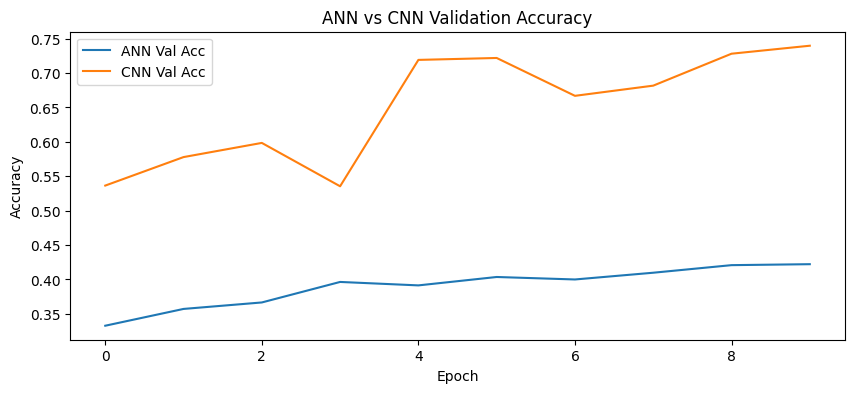

In [13]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [15]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

# 📊 Final Comparison Table

In [16]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_acc, cnn_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.4268
1,CNN,0.7306


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

## Task 1: Deeper ANN



In [17]:
ann_deep_model = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_deep_history = ann_deep_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 33s 45ms/step - accuracy: 0.2516 - loss: 2.0182 - val_accuracy: 0.3246 - val_loss: 1.8423
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 47ms/step - accuracy: 0.3176 - loss: 1.8721 - val_accuracy: 0.3322 - val_loss: 1.8304
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3323 - loss: 1.8254 - val_accuracy: 0.3440 - val_loss: 1.8179
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - accuracy: 0.3466 - loss: 1.7963 - val_accuracy: 0.3710 - val_loss: 1.7678
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 37s 52ms/step - accuracy: 0.3629 - loss: 1.7593 - val_accuracy: 0.3840 - val_loss: 1.7366
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - accuracy: 0.3660 - loss: 1.7446 - val_accuracy: 0.4070 - val_loss: 1.7012
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.3735 - loss: 1.7205 - val_accuracy: 0.3926 - val_loss: 1.6765
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - accuracy: 0.3848 - loss: 1.7050 - 

## Evaluate Deeper ANN


In [18]:
ann_deep_test_loss, ann_deep_test_acc = ann_deep_model.evaluate(x_test_flat, y_test)
print("Deeper ANN Test Accuracy:", ann_deep_test_acc)
print("Baseline ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.4312 - loss: 1.6127
Deeper ANN Test Accuracy: 0.4311999976634979
Baseline ANN Test Accuracy: 0.426800012588501


## Task 2: CNN with Scaled Filters (32→64→128)


In [19]:
cnn_scaled_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_scaled_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_scaled_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,706 (1.36 MB)

 Trainable params: 357,258 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

## Task 3 & 4: 20 Epochs + EarlyStopping

In [20]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

cnn_scaled_history = cnn_scaled_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 94s 130ms/step - accuracy: 0.4429 - loss: 1.5472 - val_accuracy: 0.5912 - val_loss: 1.1583
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 130ms/step - accuracy: 0.5906 - loss: 1.1659 - val_accuracy: 0.5516 - val_loss: 1.2606
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 125ms/step - accuracy: 0.6541 - loss: 0.9948 - val_accuracy: 0.6796 - val_loss: 0.9285
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 126ms/step - accuracy: 0.6929 - loss: 0.8772 - val_accuracy: 0.6766 - val_loss: 0.9253
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 144s 129ms/step - accuracy: 0.7244 - loss: 0.7846 - val_accuracy: 0.6430 - val_loss: 1.0822
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 139s 126ms/step - accuracy: 0.7511 - loss: 0.7149 - val_accuracy: 0.7436 - val_loss: 0.7699
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 145s 130ms/step - accuracy: 0.7779 - loss: 0.6408 - val_accuracy: 0.7460 - val_loss: 0.7775
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 131ms/step - accuracy: 0.7945 - l

In [21]:
cnn_scaled_test_loss, cnn_scaled_test_acc = cnn_scaled_model.evaluate(x_test_norm, y_test)
print("Scaled CNN (20 epochs + EarlyStopping) Test Accuracy:", cnn_scaled_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7507 - loss: 0.7901
Scaled CNN (20 epochs + EarlyStopping) Test Accuracy: 0.7506999969482422


## Task 5: Run Data Augmentation Training

In [26]:
aug_early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[aug_early_stop]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 59ms/step - accuracy: 0.4585 - loss: 1.5011 - val_accuracy: 0.5488 - val_loss: 1.2663
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.4980 - loss: 1.4031 - val_accuracy: 0.5546 - val_loss: 1.2776
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.5192 - loss: 1.3467 - val_accuracy: 0.5772 - val_loss: 1.1891
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 82s 60ms/step - accuracy: 0.5397 - loss: 1.2966 - val_accuracy: 0.6184 - val_loss: 1.0881
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 60ms/step - accuracy: 0.5557 - loss: 1.2613 - val_accuracy: 0.6238 - val_loss: 1.0696
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5656 - loss: 1.2296 - val_accuracy: 0.6378 - val_loss: 1.0166
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 53ms/step - accuracy: 0.5759 - loss: 1.2059 - val_accuracy: 0.6386 - val_loss: 1.0174
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 41s 58ms/step - accuracy: 0.5838 - loss: 1.1868 - 

In [27]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6706 - loss: 0.9307
Augmented CNN Test Accuracy: 0.6705999970436096


In [29]:
final_comparison = pd.DataFrame({
    "Model": [
        "ANN (baseline)",
        "CNN (baseline)",
        "ANN (deeper - Task 1)",
        "CNN (scaled filters + EarlyStopping - Task 2,3,4)",
        "CNN (augmented - Task 5)"
    ],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        ann_deep_test_acc,
        cnn_scaled_test_acc,
        aug_test_acc
    ]
})
final_comparison

,Model,Test Accuracy
0,ANN (baseline),0.4268
1,CNN (baseline),0.7306
2,ANN (deeper - Task 1),0.4312
3,"CNN (scaled filters + EarlyStopping - Task 2,3,4)",0.7507
4,CNN (augmented - Task 5),0.6706


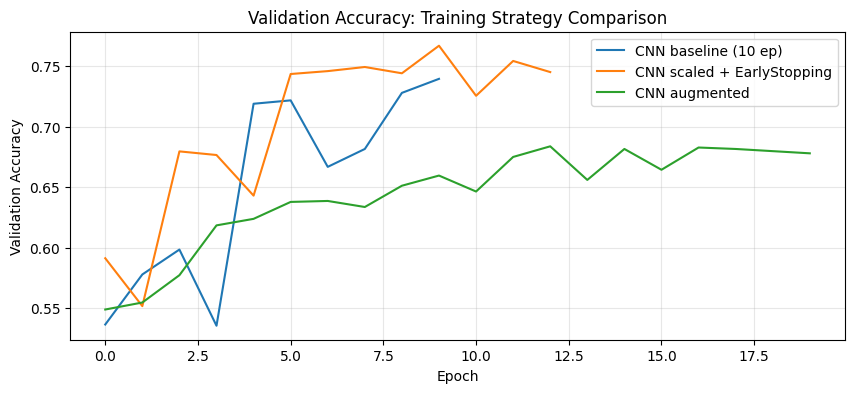

In [30]:
plt.figure(figsize=(10,4))
plt.plot(cnn_history.history['val_accuracy'], label='CNN baseline (10 ep)')
plt.plot(cnn_scaled_history.history['val_accuracy'], label='CNN scaled + EarlyStopping')
plt.plot(aug_history.history['val_accuracy'], label='CNN augmented')
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy: Training Strategy Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**